# OList E-commerce — Regression Track (Review 1)

## Objective

Predict the continuous target variable **`price`** using the OList e-commerce dataset.

This notebook is organized to satisfy **Review 1, Section C — Regression Track (9 marks)**:

- **C1:** Train all 10 required regression algorithms.
- **C2:** Compare all models using R², RMSE, and MAE on the same held-out test set.
- **C3:** Apply hyperparameter tuning to at least two models and report the improvement.
- **C4:** Produce a residual plot, predicted-vs-actual plot, and tree-based feature-importance plot.

The notebook also includes dataset auditing, EDA, written observation prompts, data cleaning, feature engineering, leakage-safe preprocessing, and 5-fold cross-validation for the two best-performing models.

> **Reproducibility:** `random_state=42` is used wherever it is applicable.

## Important modeling decisions

1. `price` is the regression target because it is continuous.
2. Duplicate rows are removed.
3. The timestamp is converted into meaningful date/time features.
4. Identifier and free-text columns are removed because they are high-cardinality or difficult to use directly in this baseline pipeline.
5. Missing values are handled inside a scikit-learn preprocessing pipeline.
6. Encoders and scalers are fitted only on the training data to avoid data leakage.
7. All standard models use the same processed train/test split.
8. Polynomial regression uses a controlled subset of numerical transformed features to prevent a very large polynomial feature matrix.
9. SVR is trained on a capped, reproducible training subset because kernel SVR can become computationally expensive on large datasets. It is still evaluated on the same held-out test set.

In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    cross_val_score
)
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TARGET = "price"

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ============================================================
# 2. LOAD THE DATASET
# ============================================================

# The first path supports a notebook running beside the CSV file.
# The second path supports the uploaded-file environment.
possible_paths = [
    Path("OList-Ecommerce.csv"),
    Path("/mnt/data/OList-Ecommerce.csv")
]

DATA_PATH = next((path for path in possible_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "OList-Ecommerce.csv was not found. "
        "Place the CSV in the notebook directory or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded from: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset loaded from: OList-Ecommerce.csv
Dataset shape: (32995, 17)


,order_id,customer_id,order_purchase_timestamp,order_status,customer_city,customer_state,product_id,seller_id,price,freight_value,review_score,review_comment_title,review_comment_message,seller_city,seller_state,product_weight_g,product_category_name_english
0,0006ec9db01a64e59a68b2c340bf65a7,5d178120c29c61748ea95bac23cb8f25,2018-07-24 17:04:17,delivered,rio de janeiro,RJ,99a4788cb24856965c36a24e339b6058,4a3ca9315b744ce9f8e9374361493884,74.0,23.32,5.0,Boa,Excelente serviço de compras on line.,ibitinga,SP,1383,bed_bath_table
1,0009c9a17f916a706d71784483a5d643,8a250edc40ebc5c3940ebc940f16a7eb,2018-04-25 09:10:41,delivered,campinas,SP,3f27ac8e699df3d300ec4a5d8c5cf0b2,fcb5ace8bcc92f75707dc0f01a27d269,639.0,11.34,4.0,NaN,NaN,guarulhos,SP,200,consoles_games
2,000aed2e25dbad2f9ddb70584c5a2ded,fff5169e583fd07fac9fec88962f189d,2018-05-11 20:33:38,delivered,santa barbara d'oeste,SP,4fa33915031a8cde03dd0d3e8fb27f01,fe2032dab1a61af8794248c8196565c9,144.0,8.77,NaN,NaN,NaN,campinas,SP,468,perfumery
3,002175704e8b209f61b9ad5cfd92b60e,a562db3c7cb9a68947debd30879b491e,2018-04-22 12:13:25,delivered,araraquara,SP,e6b6e13cf71449a457269f425b89dc74,b2ba3715d723d245138f291a6fe42594,109.9,13.21,4.0,Recomendo,Produto como descrito. Mas não gostei pq o som...,sao paulo,SP,588,audio
4,930fff097a9427c8a9a70559aa36fa76,dc56b538928bb9f7212da239e24cda3d,2018-08-22 11:52:54,delivered,maua,SP,5d6bea33648f018dbb563f3a2fab09f3,1025f0e2d44d7041d6cf58b6550e0bfa,159.8,16.42,2.0,NaN,Produto lindo! De ótima qualidade,sao paulo,SP,4000,furniture_decor


In [ ]:
# ============================================================
# 3. DATASET AUDIT
# ============================================================

print("Data types and non-null counts:")
df.info()

print("\nStatistical summary:")
display(df.describe(include="all").T)

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

print("\nMissing-value summary:")
display(missing_summary[missing_summary["missing_count"] > 0])

duplicate_count = df.duplicated().sum()
print(f"Number of completely duplicated rows: {duplicate_count}")
print(f"Duplicate percentage: {(duplicate_count / len(df) * 100):.2f}%")

print(f"Missing values in target '{TARGET}': {df[TARGET].isna().sum()}")

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 32995 entries, 0 to 32994
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       32995 non-null  str    
 1   customer_id                    32995 non-null  str    
 2   order_purchase_timestamp       32995 non-null  str    
 3   order_status                   32995 non-null  str    
 4   customer_city                  32995 non-null  str    
 5   customer_state                 32995 non-null  str    
 6   product_id                     32995 non-null  str    
 7   seller_id                      32995 non-null  str    
 8   price                          32995 non-null  float64
 9   freight_value                  32995 non-null  float64
 10  review_score                   23435 non-null  float64
 11  review_comment_title           9090 non-null   str    
 12  review_comment_message   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,32995,28891,af822dacd6f5cff7376413c03a388bb7,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,32995,28891,9eb3d566e87289dcb0acf28e1407c839,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,32995,28745,2018-06-08 16:42:11,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,32995,5,delivered,32514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_city,32995,2521,sao paulo,5953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,32995,27,SP,15290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,32995,13359,53b36df67ebb7c41585e8d54d6772e08,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_id,32995,2034,6560211a19b47992c3666cc44a7e94c0,772,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,32995.0,NaN,NaN,NaN,123.072503,194.338391,0.85,39.99,77.9,134.99,6729.0
freight_value,32995.0,NaN,NaN,NaN,21.0615,18.291288,0.0,12.79,18.2,22.98,375.28



Missing-value summary:


,missing_count,missing_percentage
review_comment_title,23905,72.45
review_comment_message,23406,70.94
review_score,9560,28.97


Number of completely duplicated rows: 2951
Duplicate percentage: 8.94%
Missing values in target 'price': 0


### Dataset audit — written observation

The audit reports the dataset dimensions, data types, missing-value counts, duplicate count, and target completeness.

When presenting this section, explain:

- Whether the target contains missing values.
- Which columns have the most missing values.
- Why duplicate rows should be removed before model training.
- Why identifier and free-text columns require special treatment.

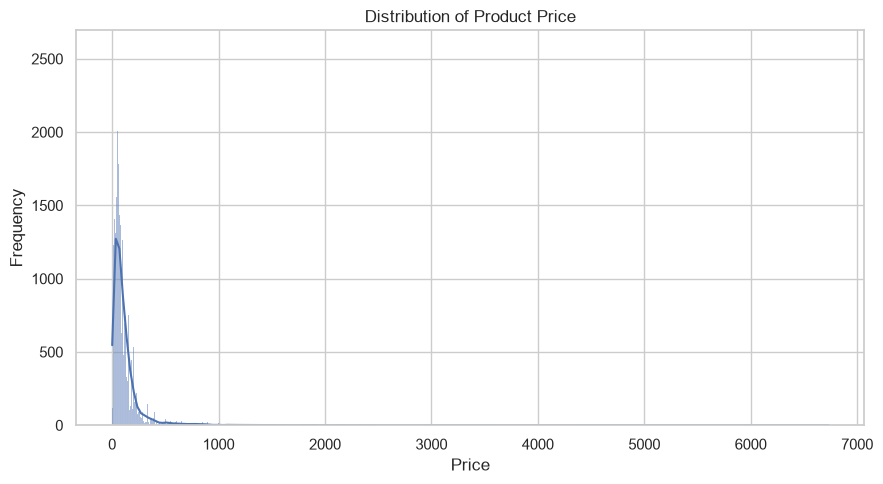

Target statistics:


count    32995.000000
mean       123.072503
std        194.338391
min          0.850000
25%         39.990000
50%         77.900000
75%        134.990000
max       6729.000000
Name: price, dtype: float64

Target skewness: 8.069


In [ ]:
# ============================================================
# 4. TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))
sns.histplot(df[TARGET].dropna(), kde=True)
plt.title("Distribution of Product Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Target statistics:")
display(df[TARGET].describe())
print(f"Target skewness: {df[TARGET].skew():.3f}")

### Target-distribution observation

Use the displayed histogram and skewness value to comment on:

- Whether prices are approximately symmetric or right-skewed.
- Whether a small number of high-priced products may influence the regression models.
- Why MAE and RMSE are both reported: RMSE gives more weight to large errors.

In [ ]:
# ============================================================
# 5. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ============================================================

numeric_columns_initial = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns_initial = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:")
print(numeric_columns_initial)

print("\nCategorical/object columns:")
print(categorical_columns_initial)

Numerical columns:
['price', 'freight_value', 'review_score', 'product_weight_g']

Categorical/object columns:
['order_id', 'customer_id', 'order_purchase_timestamp', 'order_status', 'customer_city', 'customer_state', 'product_id', 'seller_id', 'review_comment_title', 'review_comment_message', 'seller_city', 'seller_state', 'product_category_name_english']


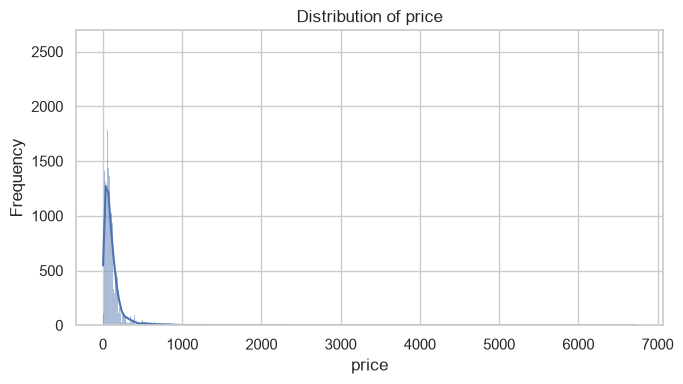

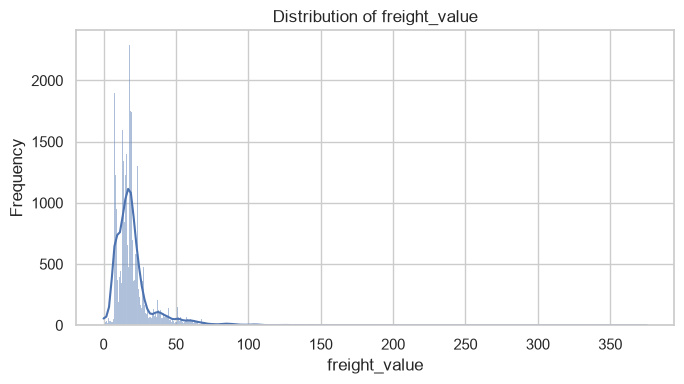

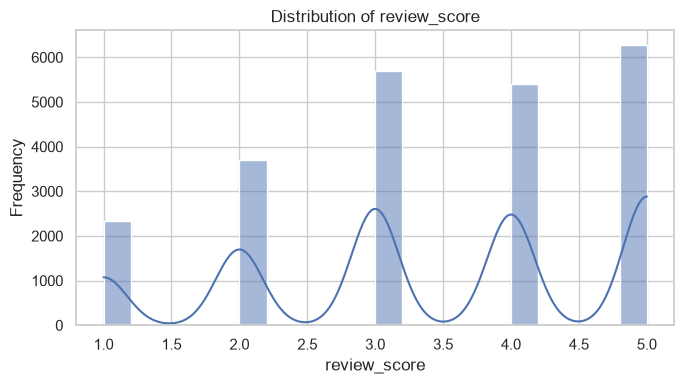

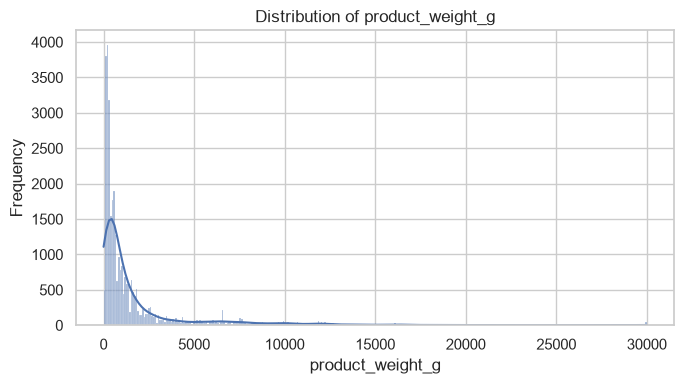

In [ ]:
# ============================================================
# 6. NUMERICAL FEATURE DISTRIBUTIONS
# ============================================================

# Plot every numerical feature separately so that each feature
# can be inspected without overlapping scales.
for column in numeric_columns_initial:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[column].dropna(), kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Numerical-distribution observation

For each numerical feature, identify visible concentration, skewness, or extreme values.

Do not automatically delete every extreme value. In an e-commerce dataset, high prices, large freight values, and large product weights may be legitimate observations.

order_id: 28891 unique values


order_id
af822dacd6f5cff7376413c03a388bb7    12
c05d6a79e55da72ca780ce90364abed9    12
637617b3ffe9e2f7a2411243829226d0    12
6c355e2913545fa6f72c40cbca57729e    11
ca3625898fbd48669d50701aba51cd5f    10
e8fa22c3673b1dd17ea315021b1f0f61    10
0c82a229fc22597c2361656cba8d3230     7
7d8f5bfd5aff648220374a2df62e84d5     7
9bdf94af058f959fbc09c3ea1eb32465     7
e332eda82fe7ca4e86daf4f71ca785df     7
Name: count, dtype: int64

customer_id: 28891 unique values


customer_id
9eb3d566e87289dcb0acf28e1407c839    12
3b54b5978e9ace64a63f90d176ffb158    12
daf15f1b940cc6a72ba558f093dc00dd    12
d95ca02ab50105ccce682bdf9ffdc3b4    11
0d861a5e4dd6a9079d89e1330848f0ab    10
1ff773612ab8934db89fd5afa8afe506    10
9ae4bf2bb990fa503baa7e1feaf6f60e     7
a67a246af6ba598a14cc86df3c0354ee     7
64ece241ae357ffb4989f7970a6f6adf     7
159132ab31eb3c8a1061ed18967f720b     7
Name: count, dtype: int64

order_purchase_timestamp: 28745 unique values


order_purchase_timestamp
2018-06-08 16:42:11    12
2018-05-13 13:05:02    12
2018-04-17 21:08:59    12
2018-07-25 14:47:45    11
2018-08-12 02:11:20    10
2018-04-19 13:54:06    10
2018-05-15 16:10:38     7
2018-05-12 22:27:38     7
2018-04-19 11:17:55     7
2018-06-05 14:38:19     7
Name: count, dtype: int64

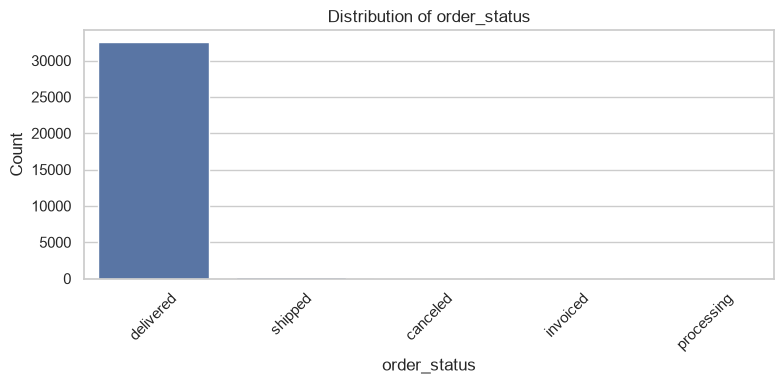

customer_city: 2521 unique values


customer_city
sao paulo                5953
rio de janeiro           2084
belo horizonte            932
brasilia                  757
curitiba                  525
campinas                  502
guarulhos                 485
porto alegre              434
salvador                  416
sao bernardo do campo     318
Name: count, dtype: int64

customer_state: 27 unique values


customer_state
SP    15290
RJ     3867
MG     3619
RS     1669
PR     1667
SC     1130
BA     1042
DF      757
ES      620
GO      617
Name: count, dtype: int64

product_id: 13359 unique values


...

review_comment_title
NaN                23905
Recomendo            327
recomendo            279
Excelente            206
Bom                  206
super recomendo      201
Ótimo                191
Muito bom            181
Super recomendo      164
Ótimo                153
Name: count, dtype: int64

review_comment_message: 7413 unique values


review_comment_message
NaN          23406
Muito bom       55
muito bom       35
Bom             31
Otimo           28
Ótimo           22
bom             20
Ótimo           19
ok              16
otimo           15
Name: count, dtype: int64

seller_city: 464 unique values


seller_city
sao paulo                8577
ibitinga                 1938
guarulhos                 892
rio de janeiro            869
curitiba                  836
belo horizonte            694
ribeirao preto            662
salto                     622
campinas                  620
sao jose do rio preto     604
Name: count, dtype: int64

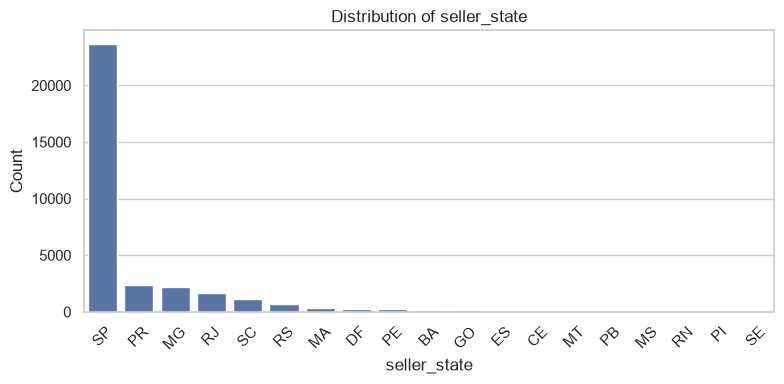

product_category_name_english: 70 unique values


product_category_name_english
health_beauty            3620
bed_bath_table           3148
housewares               2657
watches_gifts            2364
furniture_decor          2169
sports_leisure           2118
computers_accessories    1950
auto                     1485
telephony                1116
baby                     1020
Name: count, dtype: int64

In [ ]:
# ============================================================
# 7. CATEGORICAL FEATURE DISTRIBUTIONS
# ============================================================

# Count plots are shown only for low-cardinality columns.
# High-cardinality columns are summarized through value counts.
for column in categorical_columns_initial:
    unique_count = df[column].nunique(dropna=False)

    if unique_count <= 20:
        plt.figure(figsize=(8, 4))
        order = df[column].fillna("Missing").value_counts().index
        sns.countplot(
            data=df.assign(**{column: df[column].fillna("Missing")}),
            x=column,
            order=order
        )
        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print(f"{column}: {unique_count} unique values")
        display(df[column].value_counts(dropna=False).head(10))

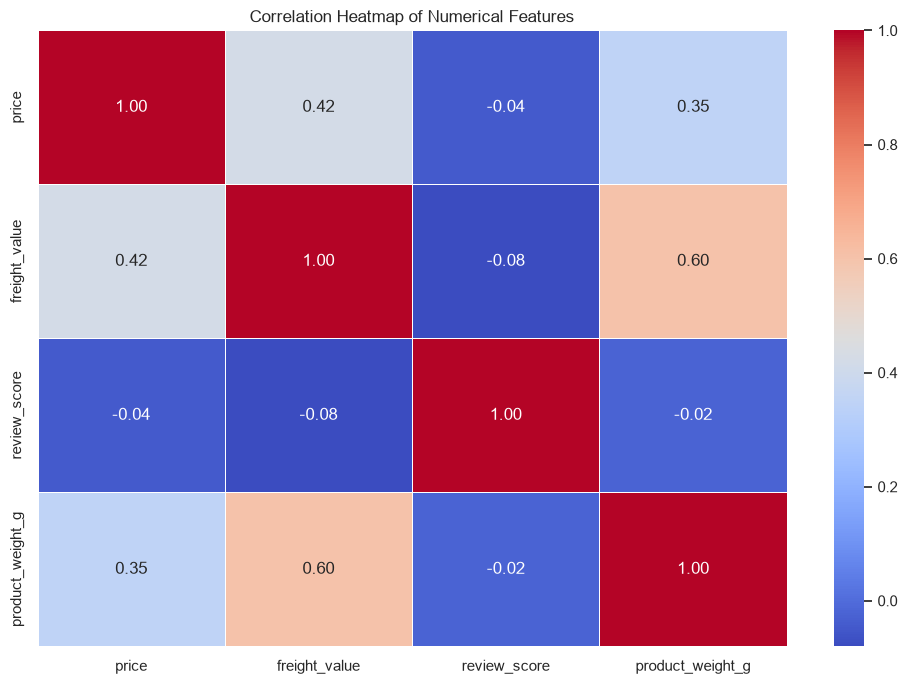

Numerical feature correlations with price:


,correlation
freight_value,0.421029
product_weight_g,0.346716
review_score,-0.043951


In [ ]:
# ============================================================
# 8. CORRELATION HEATMAP
# ============================================================

numeric_for_corr = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_for_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

target_correlations = (
    numeric_for_corr.corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)

print("Numerical feature correlations with price:")
display(target_correlations.to_frame("correlation"))

### Correlation-heatmap observation

Use the heatmap and correlation table to discuss:

- Which numerical features have the strongest positive or negative linear relationship with `price`.
- Whether any numerical predictors are strongly correlated with each other.
- Why correlation does not prove causation and may not capture non-linear relationships.

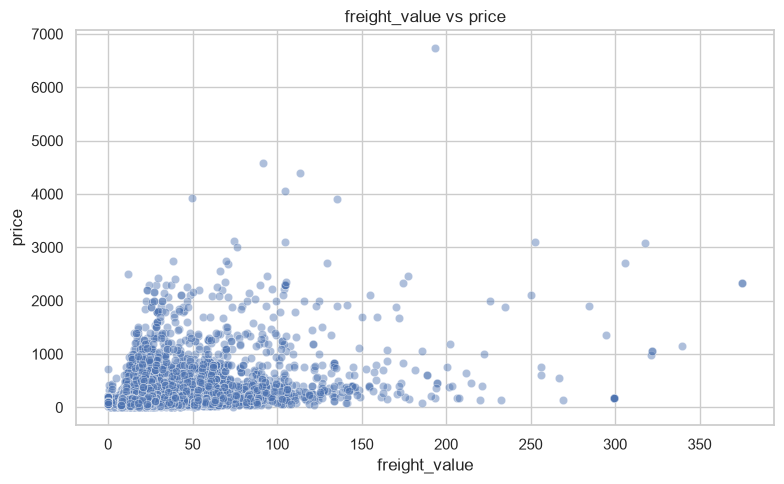

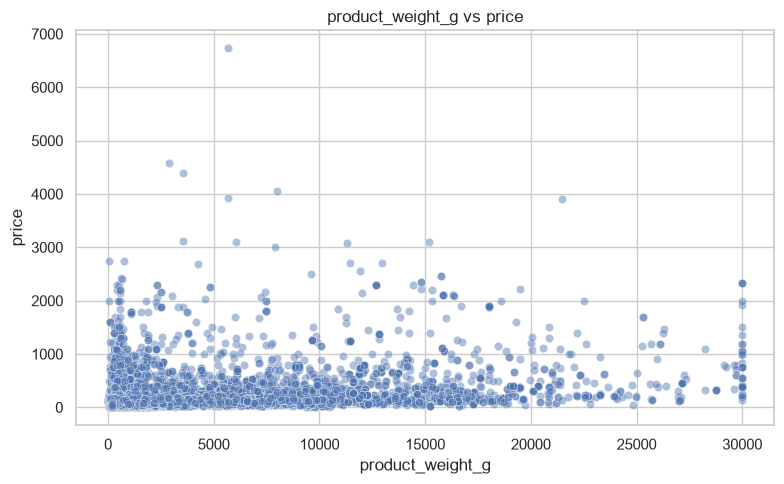

Features selected for target scatter plots: ['freight_value', 'product_weight_g']


In [ ]:
# ============================================================
# 9. TWO FEATURE-TARGET SCATTER PLOTS
# ============================================================

# Select up to two numerical features with the strongest absolute
# correlation with the target. This makes the scatter plots data-driven.
top_scatter_features = target_correlations.abs().head(2).index.tolist()

for feature in top_scatter_features:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=df,
        x=feature,
        y=TARGET,
        alpha=0.45
    )
    plt.title(f"{feature} vs {TARGET}")
    plt.xlabel(feature)
    plt.ylabel(TARGET)
    plt.tight_layout()
    plt.show()

print("Features selected for target scatter plots:", top_scatter_features)

### Scatter-plot observation

For each scatter plot, comment on:

- Whether the relationship appears positive, negative, weak, or non-linear.
- Whether the points contain visible clusters or extreme observations.
- Whether the plot supports using a linear model alone or motivates testing non-linear models.

In [ ]:
# ============================================================
# 10. REMOVE DUPLICATES AND HANDLE THE TARGET
# ============================================================

rows_before = len(df)

# Remove exact duplicate records.
df = df.drop_duplicates().reset_index(drop=True)

# Rows without a target cannot be used for supervised regression.
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

print(f"Rows before cleaning: {rows_before}")
print(f"Rows after duplicate removal and target cleaning: {len(df)}")
print(f"Remaining missing target values: {df[TARGET].isna().sum()}")

Rows before cleaning: 32995
Rows after duplicate removal and target cleaning: 30044
Remaining missing target values: 0


In [ ]:
# ============================================================
# 11. TIMESTAMP FEATURE ENGINEERING
# ============================================================

# Convert the timestamp safely. Invalid timestamps become NaT.
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"],
    errors="coerce"
)

# Extract useful calendar/time information.
df["purchase_year"] = df["order_purchase_timestamp"].dt.year
df["purchase_month"] = df["order_purchase_timestamp"].dt.month
df["purchase_day"] = df["order_purchase_timestamp"].dt.day
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour
df["purchase_dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek

print("Engineered timestamp features:")
print([
    "purchase_year",
    "purchase_month",
    "purchase_day",
    "purchase_hour",
    "purchase_dayofweek"
])

Engineered timestamp features:
['purchase_year', 'purchase_month', 'purchase_day', 'purchase_hour', 'purchase_dayofweek']


### Feature-engineering justification

The timestamp is transformed into year, month, day, hour, and day-of-week features because purchasing patterns can vary by season, month, time of day, and weekday.

The original timestamp is removed later because most scikit-learn estimators cannot directly use a raw datetime column in this pipeline.

In [ ]:
# ============================================================
# 12. OUTLIER AUDIT USING THE IQR METHOD
# ============================================================

# The IQR method is used for auditing, not for blindly deleting
# legitimate high-value products.
numeric_columns_after_engineering = df.select_dtypes(include=np.number).columns.tolist()

outlier_rows = []

for column in numeric_columns_after_engineering:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    count = int(outlier_mask.sum())

    outlier_rows.append({
        "feature": column,
        "outlier_count": count,
        "outlier_percentage": round(count / len(df) * 100, 2),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values(
    "outlier_count", ascending=False
)

display(outlier_summary)

,feature,outlier_count,outlier_percentage,lower_bound,upper_bound
3,product_weight_g,4045,13.46,-1875.00000,3845.00000
1,freight_value,2960,9.85,-2.52375,38.36625
0,price,2301,7.66,-103.50000,284.50000
2,review_score,0,0.00,-1.00000,7.00000
4,purchase_year,0,0.00,2018.00000,2018.00000
5,purchase_month,0,0.00,2.00000,10.00000
6,purchase_day,0,0.00,-14.50000,45.50000
7,purchase_hour,0,0.00,-1.00000,31.00000
8,purchase_dayofweek,0,0.00,-3.50000,8.50000


### Outlier-treatment decision

The IQR output identifies potential outliers, but the project retains observations unless there is evidence that they are invalid.

This is appropriate for e-commerce data because unusually expensive products or large freight values may be genuine business records. The models are evaluated with MAE and RMSE so that the effect of large errors can be observed.

In [ ]:
# ============================================================
# 13. DEFINE FEATURES AND REMOVE UNSUITABLE COLUMNS
# ============================================================

# Separate target and predictors.
X = df.drop(columns=[TARGET])
y = df[TARGET].copy()

# These columns are removed because they are:
# - unique identifiers,
# - free-text review fields, or
# - raw datetime values that are replaced by engineered features.
columns_to_drop = [
    "order_id",
    "customer_id",
    "product_id",
    "seller_id",
    "review_comment_title",
    "review_comment_message",
    "order_purchase_timestamp"
]

X = X.drop(columns=columns_to_drop, errors="ignore")

print("Final raw feature columns:")
print(X.columns.tolist())
print(f"Feature matrix shape before splitting: {X.shape}")
print(f"Target shape: {y.shape}")

Final raw feature columns:
['order_status', 'customer_city', 'customer_state', 'freight_value', 'review_score', 'seller_city', 'seller_state', 'product_weight_g', 'product_category_name_english', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_hour', 'purchase_dayofweek']
Feature matrix shape before splitting: (30044, 14)
Target shape: (30044,)


In [ ]:
# ============================================================
# 14. TRAIN-TEST SPLIT
# ============================================================

# Use one fixed split for fair comparison of all models.
# Stratification is not appropriate for continuous regression targets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (24035, 14)
Testing feature shape: (6009, 14)
Training target shape: (24035,)
Testing target shape: (6009,)


In [ ]:
# ============================================================
# 15. LEAKAGE-SAFE PREPROCESSING PIPELINE
# ============================================================

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Numerical columns:
# 1. Median imputation handles missing numerical values.
# 2. StandardScaler is important for Ridge, Lasso, ElasticNet,
#    SVR, KNN, and polynomial regression.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical columns:
# 1. Most-frequent imputation fills missing categories.
# 2. One-hot encoding converts categories into numerical columns.
# 3. min_frequency reduces extremely rare categories and helps
#    control the number of generated columns.
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=10,
        sparse_output=True
    )
except TypeError:
    # Compatibility with older scikit-learn versions.
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=10,
        sparse=True
    )

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", one_hot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Fit only on training data; then transform both training and test data.
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Numerical features: ['freight_value', 'review_score', 'product_weight_g', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_hour', 'purchase_dayofweek']
Categorical features: ['order_status', 'customer_city', 'customer_state', 'seller_city', 'seller_state', 'product_category_name_english']
Processed training shape: (24035, 634)
Processed testing shape: (6009, 634)


### Preprocessing justification

The preprocessing object is fitted only on `X_train`.

This prevents data leakage because:

- Imputation values are learned from the training data.
- Scaling parameters are learned from the training data.
- Categorical levels are learned from the training data.
- The test set is transformed using the already-fitted preprocessing object.

In [ ]:
# ============================================================
# 16. PREPARE DATA FOR MODELS
# ============================================================

# Some estimators accept sparse matrices, while others require
# dense arrays. The dataset is kept in a dense representation
# for consistent use across the required regression algorithms.
X_train_model = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else np.asarray(X_train_processed)
X_test_model = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else np.asarray(X_test_processed)

print("Dense training matrix shape:", X_train_model.shape)
print("Dense testing matrix shape:", X_test_model.shape)

# Polynomial regression is applied to a controlled subset of the
# numerical transformed columns. This avoids an uncontrolled
# explosion in the number of polynomial features.
poly_feature_count = min(5, len(numeric_features))
X_train_poly_base = X_train_model[:, :poly_feature_count]
X_test_poly_base = X_test_model[:, :poly_feature_count]

print("Number of numerical features used for polynomial expansion:", poly_feature_count)

Dense training matrix shape: (24035, 634)
Dense testing matrix shape: (6009, 634)
Number of numerical features used for polynomial expansion: 5


In [ ]:
# ============================================================
# 17. EVALUATION FUNCTION
# ============================================================

def calculate_regression_metrics(y_true, y_pred):
    """Return the required Review 1 regression metrics."""
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

def evaluate_and_store(model_name, model, X_fit, y_fit, X_eval, y_eval, results, predictions):
    """Fit a model, generate predictions, and store metrics."""
    model.fit(X_fit, y_fit)
    prediction = model.predict(X_eval)

    metrics = calculate_regression_metrics(y_eval, prediction)
    metrics["Model"] = model_name

    results.append(metrics)
    predictions[model_name] = prediction

    print(f"{model_name} completed.")
    print(
        f"R2={metrics['R2']:.4f}, "
        f"RMSE={metrics['RMSE']:.4f}, "
        f"MAE={metrics['MAE']:.4f}"
    )

    return model

# Section C1 — Implementation of the first 5 regression algorithms

The first five regression algorithms are trained below. The same held-out test set is used for evaluation.

The polynomial model uses the controlled numerical subset described earlier.

In [ ]:
# ============================================================
# 18. TRAIN THE FIRST 5 REGRESSION MODELS
# ============================================================

results = []
predictions = {}
trained_models = {}

# 1. Linear Regression — baseline model.
trained_models["Linear Regression"] = evaluate_and_store(
    "Linear Regression",
    LinearRegression(),
    X_train_model, y_train,
    X_test_model, y_test,
    results, predictions
)

# 2. Ridge Regression — L2 regularization.
trained_models["Ridge Regression"] = evaluate_and_store(
    "Ridge Regression",
    Ridge(alpha=1.0),
    X_train_model, y_train,
    X_test_model, y_test,
    results, predictions
)

# 3. Lasso Regression — L1 regularization.
trained_models["Lasso Regression"] = evaluate_and_store(
    "Lasso Regression",
    Lasso(alpha=0.001, max_iter=5000),
    X_train_model, y_train,
    X_test_model, y_test,
    results, predictions
)

# 4. ElasticNet — combined L1 and L2 regularization.
trained_models["ElasticNet Regression"] = evaluate_and_store(
    "ElasticNet Regression",
    ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
    X_train_model, y_train,
    X_test_model, y_test,
    results, predictions
)

# 5. Polynomial Regression.
# PolynomialFeatures is applied to a controlled numerical subset.
poly_model = Pipeline(steps=[
    ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear_regression", LinearRegression())
])

trained_models["Polynomial Regression"] = evaluate_and_store(
    "Polynomial Regression",
    poly_model,
    X_train_poly_base, y_train,
    X_test_poly_base, y_test,
    results, predictions
)


Linear Regression completed.
R2=0.3117, RMSE=178.8864, MAE=78.7613
Ridge Regression completed.
R2=0.3133, RMSE=178.6852, MAE=78.5198
Lasso Regression completed.
R2=0.3123, RMSE=178.8135, MAE=78.6107
ElasticNet Regression completed.
R2=0.3152, RMSE=178.4409, MAE=77.7121
Polynomial Regression completed.
R2=0.1823, RMSE=194.9785, MAE=85.5739
